# Iterated Function Systems

[Moreno Marzolla](https://www.moreno.marzolla.name)

Written in March 2026.

Last modified June 2026.

---

## Affine transformations

An _affine transformation_ is a tuple $(a, b, c, d, e, f)$ that maps a point $(x, y)$ to the new coordinates $(ax + by + e, cx + dy + f)$. This can be expressed in matrix form as:

$$
f(x,y) = \begin{pmatrix}
a & b \\
c & d 
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
+
\begin{pmatrix}
e \\
f
\end{pmatrix}
$$

By choosing suitable parameter values, an affine transformation can represent any combination of translation, rotation, and linear stretching.

In [45]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import itertools as it

def affine(p, transformation):
    """
    Transform point `p=(x,y)` according to affine `transformation=(a,b,c,d,e,f)`.
    Return the transformed point `p'=(x',y')`.    
    """
    a, b, c, d, e, f = transformation
    x, y = p
    return (a*x + b*y + e), (c*x + d*y + f)

It can be useful to define a Python function `show_affine(t)` that graphically displays the effect of an affine transformation $t$ applied to the unitary square.

In [46]:
def show_affine(t):
    """
    Apply an affine transformation to the unitary square; useful for displaying what a transformation does.
    """
    square = np.matrix([affine([0,0], t),
                        affine([0,1], t),
                        affine([1,1], t),
                        affine([1,0], t),
                        affine([0,0], t)])
    x, y = square[:, 0], square[:, 1]
    plt.fill(x, y, alpha=0.5)
    plt.plot(x, y)
    el = np.matrix([affine([0.1, 0.9], t),
                    affine([0.1, 0.1], t),
                    affine([0.9, 0.1], t)])
    plt.plot(el[:, 0], el[:,1], 'k')

## Defining transformations

For example, a counterclockwise rotation of $\theta$ radians arond the origin can be represented as:

$$
f(x,y) = 
\begin{pmatrix}
\cos \theta & -\sin \theta \\
\sin \theta & \cos \theta 
\end{pmatrix}
\begin{pmatrix}
x \\
y
\end{pmatrix}
$$

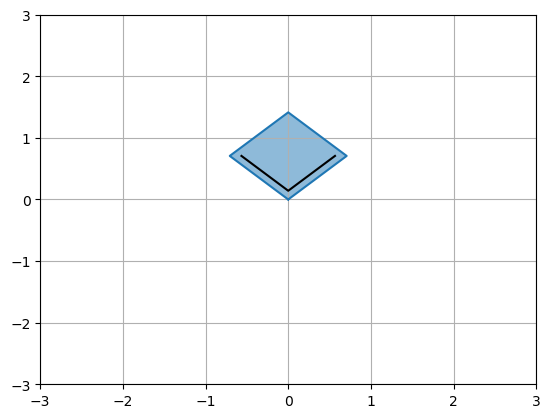

In [47]:
theta = np.pi / 4 # 45 degrees counterclockwise

show_affine([np.cos(theta), -np.sin(theta), np.sin(theta), np.cos(theta), 0, 0])
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.grid(True)

A translation along the vector $(p, q)$ can be expressed as:

$$
f(x,y) = 
\begin{pmatrix}
1 & 0 \\
0 & 1 
\end{pmatrix}
\begin{pmatrix}
p \\
q
\end{pmatrix}
$$

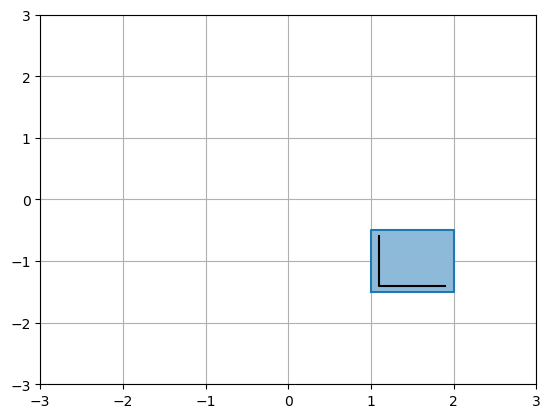

In [48]:
p,q = 1, -1.5

show_affine([1, 0, 0, 1, p, q])
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.grid(True)

A linear dilation of $dx, dy$ 

$$
f(x,y) = 
\begin{pmatrix}
dx & 0 \\
0 & dy 
\end{pmatrix}
\begin{pmatrix}
p \\
q
\end{pmatrix}
$$

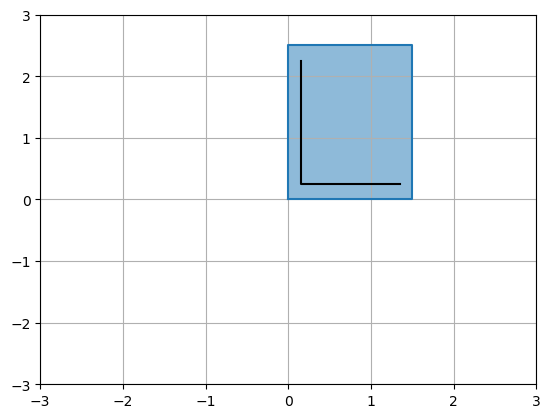

In [49]:
dx,dy = 1.5, 2.5
show_affine([dx, 0, 0, dy, 0, 0])
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.grid(True)

A negative dilation produces a mirrored image.

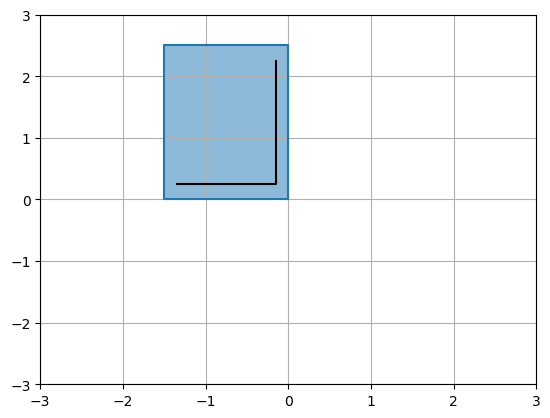

In [50]:
dx,dy = -1.5, 2.5
show_affine([dx, 0, 0, dy, 0, 0])
plt.xlim([-3,3])
plt.ylim([-3,3])
plt.grid(True)

## Iterated Function System

An _Iterated Function System_ (IFS) can be draw through an iterative procedure, as follows. We start with a matrix $M \in \mathbb{R}^{P \times 6}$ with $P$ rows and six columns; each row contains the parameters of one affine transformation:

\begin{equation*}
M = \left(\begin{matrix}
a_0 & b_0 & c_0 & d_0 & e_0 & f_0 \\
a_1 & b_1 & c_1 & d_1 & e_1 & f_1 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
a_{P-1} & b_{P-1} & c_{P-1} & d_{P-1} & e_{P-1} & f_{P-1}
\end{matrix}\right)
\end{equation*}

Start with a random point $p_0$ in the unitary square; at each step apply a randomly chosen transformation to the last drawn point $p_k$ to get a new point $p_{k+1}$, and repeat. At the end of this process, we get a sequence of $n$ points $p_0, p_1, \ldots, p_{n-1}$ that represent the orbit of $p_0$ under repeated application of a random affine transformation. Draw all points, and then start all over again with a new random initial point. (there are variants of IFS that allow the user to specify the probability of each rule).

In essence, an IFS is made of the superposition of the orbits of $n$ randomly chosen initial points. The result image is an approximation of the _attractor_ of the IFS. Note that, in general, IFS are not limited to linear transformations (i.e., affine transformations); any function could be used as the basis of an IFS.

In [51]:
def apply_random_rule(p, rules, probs=None):
    """
    Applies a random affine transformation from `rules` to point `p`.
    `rule` must be a rectangular matrix with six columns; each row
    is a transformation. If the array `probs` is given, it represents
    the probabilities to choose each transformation. `probs` must be an
    array with the same length as the `rules` array, must be nonnegative
    and sum to one.
    """
    n = len(rules)
    ruleno = np.random.choice(n, p=probs)
    return affine(p, rules[ruleno])

def iterate(f, p):
    """
    Generates the infinite orbit of point `p` under repeated application of function `f`.
    """
    while True:
        yield(p)
        p = f(p)

def orbit(f, p0, n):
    """
    Returns a list of the first `n` points of the orbit of `p0` under repeated application of function `f`.
    In other words, returns the list p0, f(p0), f(f(p0)), ...
    """
    return list(it.islice(iterate(f, p0), n))

def IFS(rules, norbits=100, points_per_orbit=5000):
    """
    Draw an IFS; generate `norbits` random starting points ("seeds"), and for each seed, 
    generate an orbit of `points_per_orbit` points. This function does not discard any point
    from the orbits.
    """
    probs = np.array([np.abs(a*d-b*c) for a,b,c,d,_,_ in rules])
    # normalize probabilities
    probs = probs / probs.sum()
    for _ in range(norbits):
        p0 = np.random.rand(2)
        points = orbit(lambda p: apply_random_rule(p, rules, probs), p0, points_per_orbit)
        # Discard the first 10% of the points of the orbit.
        points = points[int(points_per_orbit*0.1):]
        x, y = zip(*points)
        plt.plot(list(x), list(y), '.k', ms=0.2)
    #plt.show()

Let us try some rule.

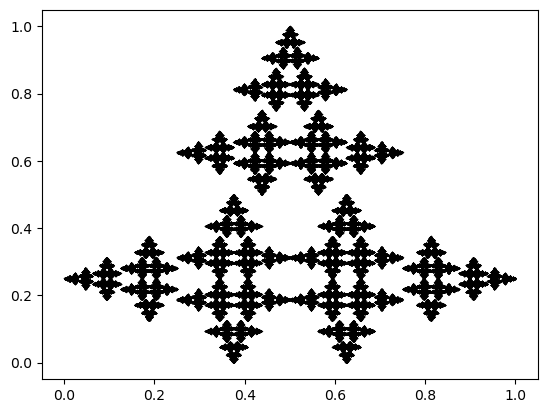

In [52]:
rule1 = [[ 0.0000, -0.5000,  0.5000,  0.0000,  0.5000,  0.0000],
         [ 0.0000,  0.5000, -0.5000,  0.0000,  0.5000,  0.5000],
         [ 0.5000,  0.0000,  0.0000,  0.5000,  0.2500,  0.5000]]

IFS(rule1)

It is difficult to understand what an affine transformation does by just looking at a table of numbers; therefore, we define a function `show_transformation(rules)` that displays `rules` in graphical form. The function scans each row of `rules`, and then plots the transformed unitary square using each transformation on `rules`.

In [53]:
def show_transformation(rules):
    """
    Display the transformation induced by `rules`;
    `rules` must be a matrix with six columns.
    """
    for r in rules:
        show_affine(r)
    #plt.show()

As an example, let us have a look at the rule above.

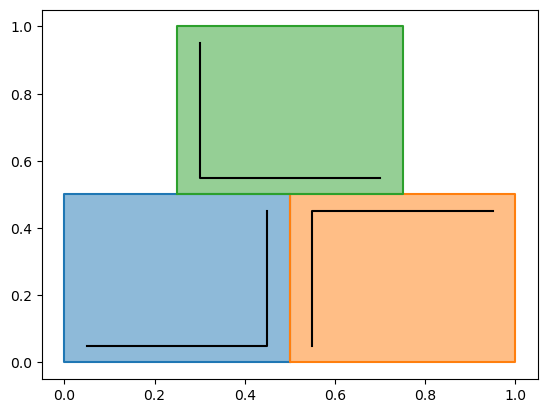

In [54]:
show_transformation(rule1)

Function `draw_IFS_and_rule()` shows the plots above side by side for easier scrutiny of the transformation and the fixed point image.

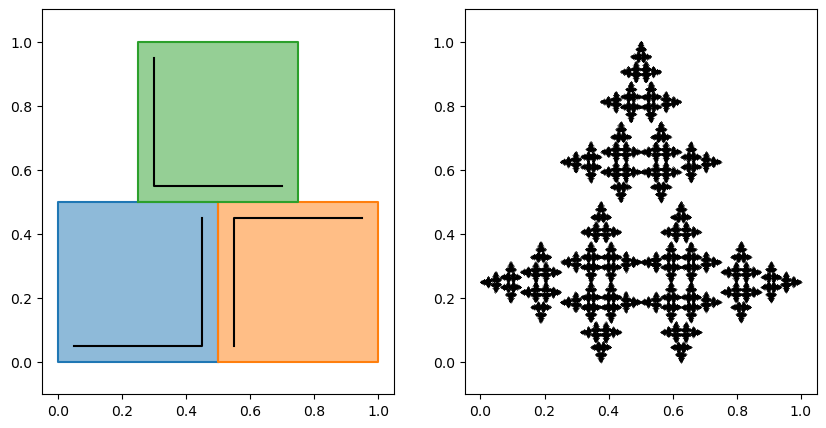

In [55]:
def draw_IFS_and_rule(rule, norbits=100, points_per_orbit=1000):
    plt.subplots(1, 2, figsize=(10,5))
    plt.subplot(1, 2, 1)    
    plt.axis('equal')
    show_transformation(rule)
    plt.subplot(1, 2, 2)
    plt.axis('equal')
    IFS(rule, norbits, points_per_orbit)
    plt.show()
    
draw_IFS_and_rule(rule1)

## A Gallery of IFS

Some of the following IFSs are suggested by Gary William Flake, "The Computational Beauty of Nature", chapter 7 _Affine Transformations_, some have been found online, and some have been written by myself.

### Sierpinski triangle

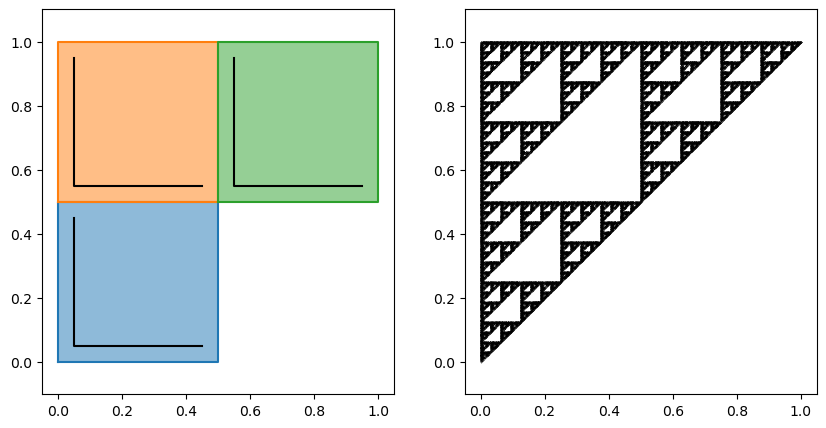

In [56]:
sierpinski = [[ 0.50, 0.00, 0.00, 0.50, 0.00, 0.00],
              [ 0.50, 0.00, 0.00, 0.50, 0.00, 0.50],
              [ 0.50, 0.00, 0.00, 0.50, 0.50, 0.50]]

draw_IFS_and_rule(sierpinski)

### Devil's staircase

The profile of this image is sometimes called _Cantor function_ or _Cantor staircase_.

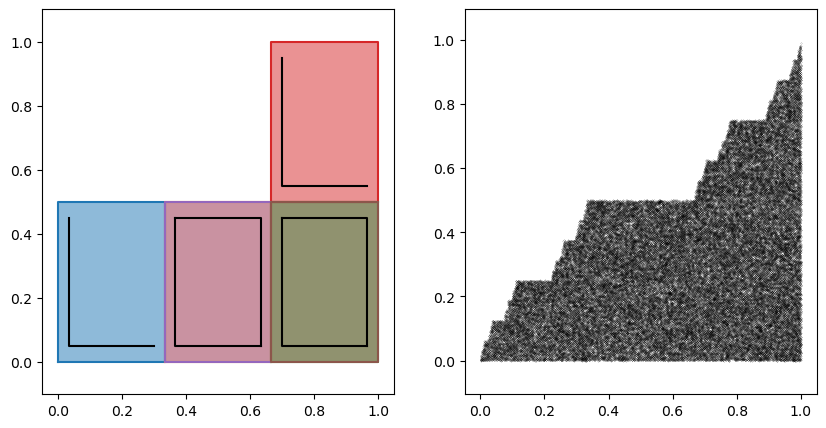

In [57]:
staircase = [[ 0.3333,  0.0000,  0.0000,  0.5000,  0.0000,  0.0000],
             [ 0.3333,  0.0000,  0.0000,  0.5000,  0.3333,  0.0000],
             [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.0000],
             [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.5000],
             [-0.3333,  0.0000,  0.0000, -0.5000,  0.6667,  0.5000],
             [-0.3333,  0.0000,  0.0000, -0.5000,  1.0000,  0.5000]]

draw_IFS_and_rule(staircase)

### Spikes

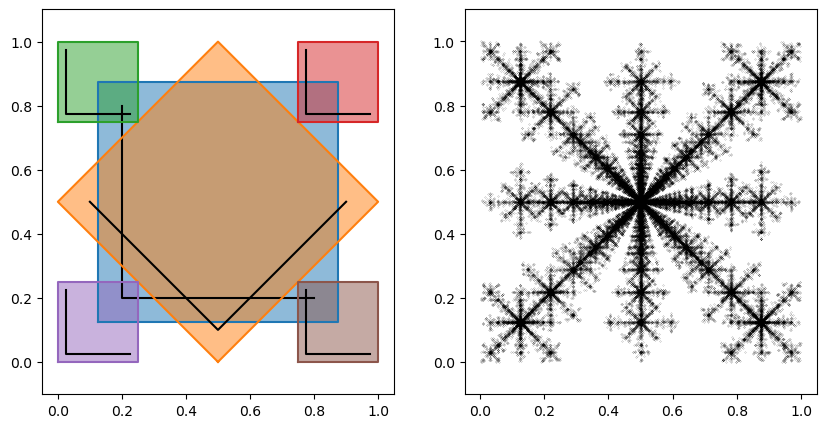

In [58]:
spikes = [[ 0.7500,  0.0000,  0.0000,  0.7500,  0.1250,  0.1250],
          [ 0.5000, -0.5000,  0.5000,  0.5000,  0.5000,  0.0000],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.7500],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.7500],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.0000],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.0000]]

draw_IFS_and_rule(spikes)

### Dragon curve

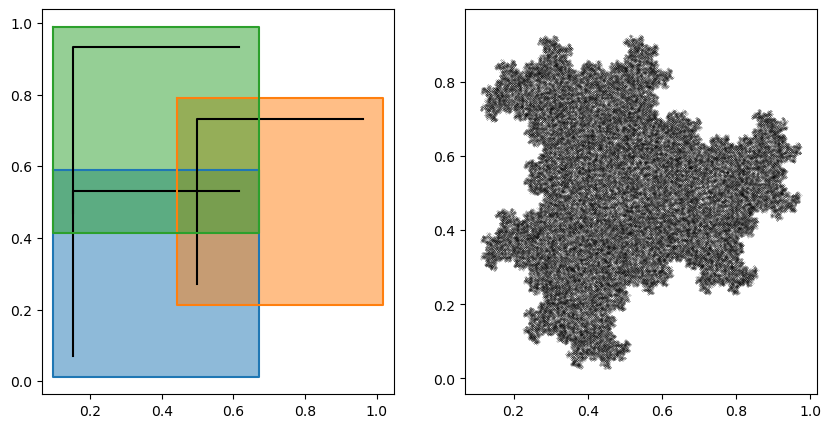

In [59]:
dragon = [[ 0.0000,  0.5770, -0.5770,  0.0000,  0.0951,  0.5893],
          [ 0.0000,  0.5770, -0.5770,  0.0000,  0.4413,  0.7893],
          [ 0.0000,  0.5770, -0.5770,  0.0000,  0.0952,  0.9893]]

draw_IFS_and_rule(dragon)

### Pine tree

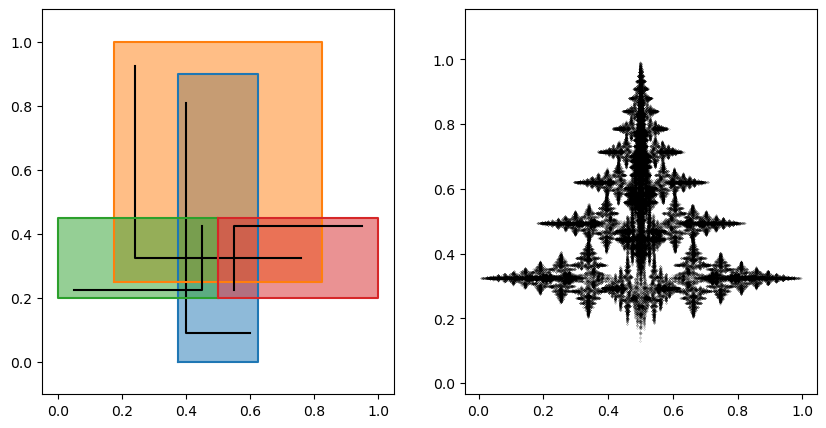

In [60]:
pine = [[ 0.2500,  0.0000,  0.0000,  0.9000,  0.3750,  0.0000],
        [ 0.6500,  0.0000,  0.0000,  0.7500,  0.1750,  0.2500],
        [ 0.0000, -0.5000,  0.2500,  0.0000,  0.5000,  0.2000],
        [ 0.0000,  0.5000, -0.2500,  0.0000,  0.5000,  0.4500]]

draw_IFS_and_rule(pine)

### Tree

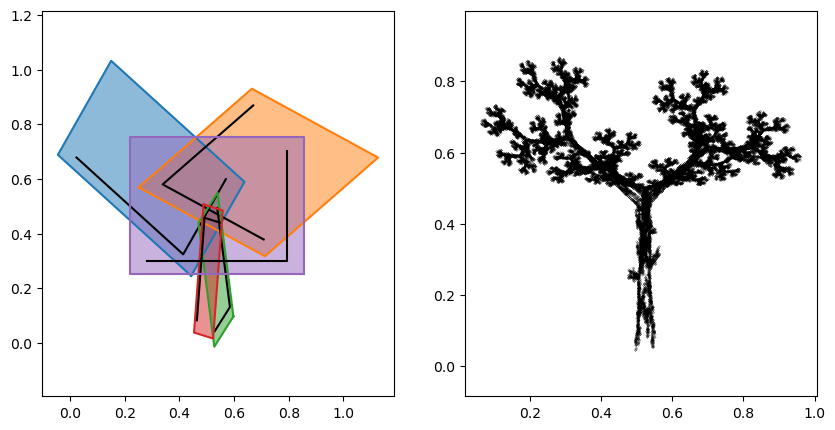

In [61]:
tree = [[ 0.1950, -0.4880,  0.3440,  0.4430,  0.4431,  0.2453],
         [ 0.4620,  0.4140, -0.2520,  0.3610,  0.2511,  0.5692],
         [-0.0580, -0.0700,  0.4530, -0.1110,  0.5976,  0.0969],
         [-0.0350,  0.0700, -0.4690, -0.0220,  0.4884,  0.5069],
         [-0.6370,  0.0000,  0.0000,  0.5010,  0.8562,  0.2513]]

draw_IFS_and_rule(tree)

### Grass

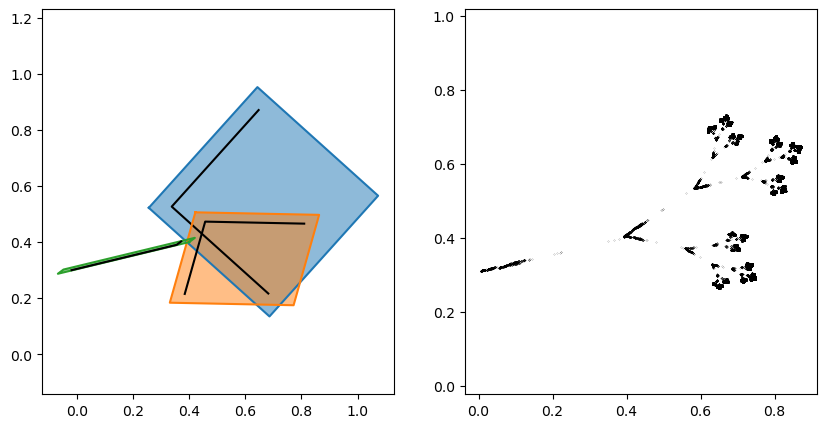

In [62]:
grass = [[ 0.3870,  0.4300,  0.4300, -0.3870,  0.2560,  0.5220],
         [ 0.4410, -0.0910, -0.0090, -0.3220,  0.4219,  0.5059],
         [-0.4680,  0.0200, -0.1130,  0.0150,  0.4000,  0.4000]]

draw_IFS_and_rule(grass)

### Grass 2

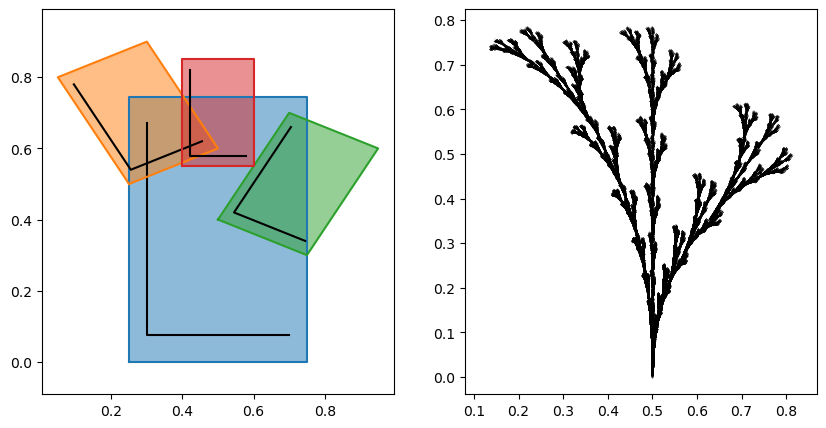

In [63]:
grass2 = [[ 0.5000,  0.0000,  0.0000,  0.7450,  0.2500,  0.0000],
          [ 0.2500, -0.2000,  0.1000,  0.3000,  0.2500,  0.5000],
          [ 0.2500,  0.2000, -0.1000,  0.3000,  0.5000,  0.4000],
          [ 0.2000,  0.0000,  0.0000,  0.3000,  0.4000,  0.5500]]

draw_IFS_and_rule(grass2)

### Barnsley's ferm

Source: <https://en.wikipedia.org/wiki/Barnsley_fern>

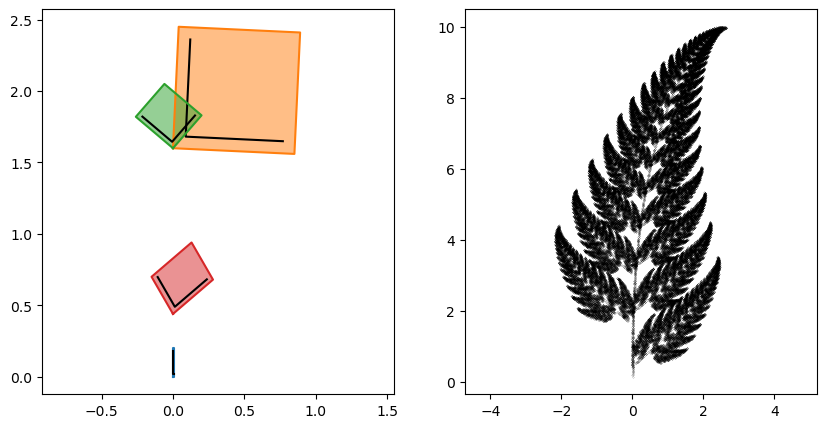

In [64]:
fern = [[ 0.01,  0.00,  0.00, 0.20, 0.00, 0.00],
        [ 0.85,  0.04, -0.04, 0.85, 0.00, 1.60],
        [ 0.20, -0.26,  0.23, 0.22, 0.00, 1.60],
        [-0.15,  0.28,  0.26, 0.24, 0.00, 0.44]]

draw_IFS_and_rule(fern)

# References

- Gary William Flake, [The Computational Beauty of Nature: Computer Explorations of Fractals, Chaos, Complex Systems, and Adaptation](https://mitpress.mit.edu/9780262561273/the-computational-beauty-of-nature/), MIT Press, 2000, ISBN 978-0262561273.
- Michael F. Barnsley, [Fractals Everywhere](https://archive.org/details/60334201FractalsEverywhere), Academic Press, 1998; a dense technical book on fractals, including Iterated Fractal Systems and L-Systems.